# Import libraries

In [1]:
import numpy as np
import pandas as pd
import re
import ssl
import nltk
import matplotlib.pyplot as plt

# Load CSVs from the /data directory

In [2]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

# Preview structure


In [3]:
df_train.head()
df_test.head()

,id,review,label
0,0,Once again Mr. Costner has dragged out a movie...,0
1,1,This is an example of why the majority of acti...,0
2,2,"First of all I hate those moronic rappers, who...",0
3,3,Not even the Beatles could write songs everyon...,0
4,4,Brass pictures (movies is not a fitting word f...,0


# Check Data Attributes and Types

In [4]:
print(df_train.info())

print(df_train['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      75000 non-null  int64 
 1   review  75000 non-null  object
 2   label   75000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ MB
None
label
-1    50000
 0    12500
 1    12500
Name: count, dtype: int64


# Check for Missing Values and Quality Issues

In [5]:
# Null/missing values
print("Missing values (train):")
print(df_train.isnull().sum())

print("Missing values (test):")
print(df_test.isnull().sum())


Missing values (train):
id        0
review    0
label     0
dtype: int64
Missing values (test):
id        0
review    0
label     0
dtype: int64


There are no missing values in either train or test datasets.
All rows contain valid IDs, reviews, and labels.

=> Don’t need to drop or impute any data at this stage

In [6]:
# Check review length distribution
df_train['review_length'] = df_train['review'].apply(lambda x: len(str(x).split()))
df_train['review_length'].describe()

count    75000.00000
mean       234.21816
std        173.75620
min          9.00000
25%        127.00000
50%        175.00000
75%        285.00000
max       2470.00000
Name: review_length, dtype: float64

Most reviews are between 127–285 words (Q1–Q3).

Mean = 234, Max = 2470 → right-skewed distribution.

# Check for Duplicate Values

In [7]:
# Checking for duplicate values
# training 
print("Number of rows before removing duplicates (train):", len(df_train))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (train):", len(df_train))

# test 
print("Number of rows before removing duplicates (test):", len(df_test))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (test):", len(df_test))


Number of rows before removing duplicates (train): 75000
Number of rows after removing duplicates (train): 75000
Number of rows before removing duplicates (test): 25000
Number of rows after removing duplicates (test): 25000


As a result, we know that there are no duplicate values exist in those DataFrames.

# Text Preprocessing

In [8]:
# Eliminate html tags
# Covert the text to lowercase.
# Remove the punctuation

def preprocess_text(text):
    # Remove HTML tags
    text = re.sub(r"<.*>", " ", text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation using regex
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_train['review'] = df_train['review'].apply(preprocess_text)
df_test['review'] = df_test['review'].apply(preprocess_text)

After preproccesing, the datasets don't contain any uppercase letters and punctuation.

# Eliminate stopwords and apply stemming or lemmatization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Build function
def tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return tokens

# Apply to dataset
df_train['tokens'] = df_train['review'].apply(tokenizer)
df_test['tokens'] = df_test['review'].apply(tokenizer)

# Display results
df_train[['review', 'tokens']].head()


,review,tokens
0,story of a man who has unnatural feelings for ...,"[story, man, unnatural, feelings, pig, starts,..."
1,airport 77 starts as a brand new luxury 747 pl...,"[airport, 77, starts, brand, new, luxury, 747,..."
2,this film lacked something i couldnt put my fi...,"[film, lacked, finger, charisma, leading, actr..."
3,sorry everyone i know this is supposed to be a...,"[sorry, know, supposed, art, film, wow, handed..."
4,when i was little my parents took me along to ...,"[little, parents, took, theater, interiors, mo..."


# Visualize class distributions (positive vs. negative reviews)

### Use sentiment analysis to differentiate the reviews with label -1 are postive (1) or negative (0)

In [10]:
# Download the vander_lexicon package for sentiment analusis
# Temporarily disable SSL certificate verification in case download problem
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
# If the older version of Python doesn't support unverified contexts
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...


True

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
train_sentiment_analyzer = SentimentIntensityAnalyzer()

# classify sentiment
def classify_sentiment(text):
    scores = train_sentiment_analyzer.polarity_scores(text)
    compound = scores['compound']
    # negative label = 0
    # positive lable = 1
    if compound >= 0:
        return 1
    else:
        return 0    

In [12]:
# Apply classification with the label equal to -1 (unsup)
# It will takes few minutes to run
mask = df_train['label'] == -1
df_train.loc[mask, 'label'] = df_train.loc[mask, 'review'].apply(classify_sentiment)

In [13]:
df_train['label'].value_counts()

label
1    45186
0    29814
Name: count, dtype: int64

As a result, we can see there is no more review with label = -1

### Visualization

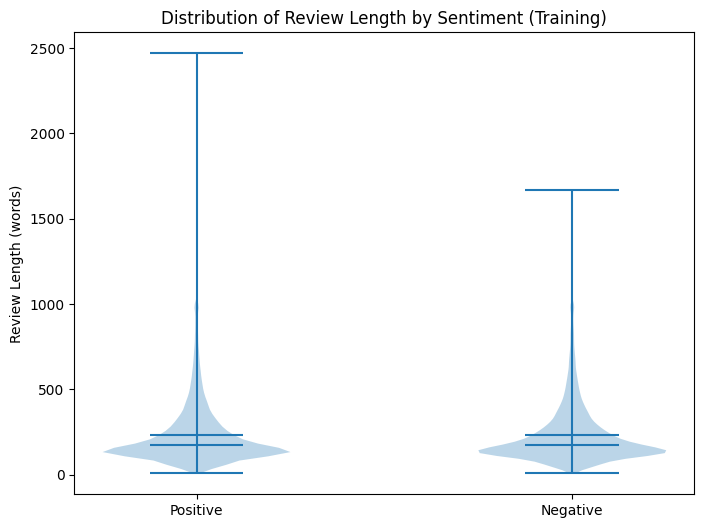

In [14]:
# positive = 1, negative = 0
df_train_positive = df_train[df_train['label'] == 1]['review_length']
df_train_negative = df_train[df_train['label'] == 0]['review_length']

# Combine data into a list
list_train_visualization = [df_train_positive, df_train_negative]

# Create the violin plot
fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(list_train_visualization, showmeans=True, showmedians=True)

# Set custom x-tick labels
ax.set_xticks([1, 2])
ax.set_xticklabels(['Positive', 'Negative'])

# Add labels and title
ax.set_ylabel('Review Length (words)')
ax.set_title('Distribution of Review Length by Sentiment (Training)')

plt.show()

As result we can see that:
- Postive reviews have a wider range, extending up to 2500 words compare to Negative only have closely 1500 words.

- According with median we can see each sentiment has almost same distribution.

- Some positive reviewers tends to write very long reivews.


# Generate word frequency distributions.

In [15]:
from collections import Counter

# Obtain positive and negative words from each class
positive_words = [word for tokens in df_train[df_train["label"] == 1]["tokens"] for word in tokens]
negative_words = [word for tokens in df_train[df_train["label"] == 0]["tokens"] for word in tokens]

# Register frequency
positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

# Convert to dataframe for visualization
df_positive_freq = pd.DataFrame(positive_freq.most_common(20), columns=['Word', 'Frequency'])
df_negative_freq = pd.DataFrame(negative_freq.most_common(20), columns=['Word', 'Frequency'])

# Display top20 frequent words for each category
print("Top 20 words for positive reviews")
print(df_positive_freq)
print("\nTop 20 words for negative reviews")
print(df_negative_freq)

Top 20 words for positive reviews
      Word  Frequency
0    movie      50011
1     film      46332
2     like      21331
3     good      18619
4     just      17136
5    great      14702
6     time      13346
7    story      13129
8   really      12548
9    films       9996
10  movies       9802
11    best       9580
12    love       9361
13  people       9269
14   watch       9045
15    dont       8581
16   think       8144
17    seen       8057
18     way       8039
19    make       7768

Top 20 words for negative reviews
      Word  Frequency
0    movie      38581
1     film      28128
2     just      14651
3     like      14490
4      bad      12211
5     good       9628
6     time       9235
7   really       8921
8     dont       7858
9    story       7198
10  movies       7014
11  people       6975
12    make       6286
13   watch       6123
14  acting       5768
15   films       5713
16    seen       5645
17    plot       5608
18     way       5479
19   think       5154


Top Frequent Words by Sentiment:

- Positive: movie, good, great, best, love

- Negative: movie, bad, boring, worst, waste

# Create word clouds for positive and negative reviews.

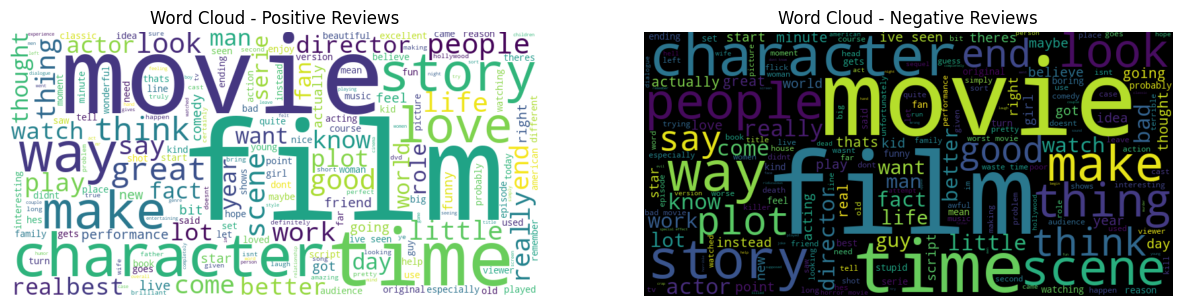

In [16]:
from wordcloud import WordCloud

# Convert words lists to text
positive_text = " ".join(positive_words)
negative_text = " ".join(negative_words)

# Create word clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
wordcloud_negative = WordCloud(width=800, height=400, background_color="black").generate(negative_text)

# Build the plot
fig, ax = plt.subplots(1, 2, figsize=(15,6))

ax[0].imshow(wordcloud_positive, interpolation='bilinear')
ax[0].set_title("Word Cloud - Positive Reviews")
ax[0].axis("off")

ax[1].imshow(wordcloud_negative, interpolation='bilinear')
ax[1].set_title("Word Cloud - Negative Reviews")
ax[1].axis("off")

plt.show()

Word Clouds:

- Clear semantic difference between positive and negative reviews.

- Positive = emotional, descriptive terms like “love”, “great”

- Negative = critical terms like “boring”, “waste”, “bad”